In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.linear.proximal_gradient import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
import logging

# Deconvolution with impulsive noise
We set up a 1D periodic deconvolution problem with impulsive noise. 
If we solve this problem by Tikhonov regularization with a quadratic data fidelity term, then the reconstruction is dominated by the effects of this impulsive noise. 

2024-06-26 21:14:51,579 INFO TikhonovCG           :: it.19 kappa=1.0182702935853458 err/Tol rel X:7.7e-07/1.0e-06 
2024-06-26 21:14:51,581 INFO TikhonovCG           :: Solver converged after 19 iteration.


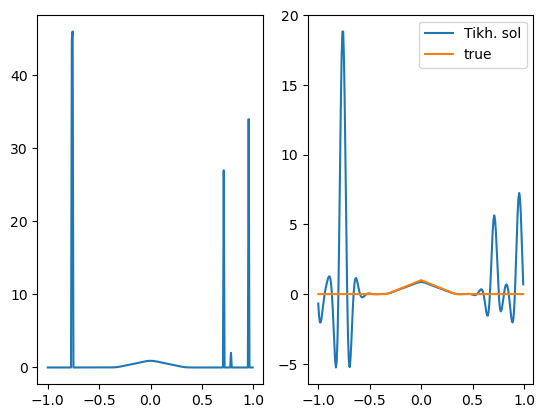

In [2]:
n = 256
sigma = 0.002
alpha = 0.1
grid = UniformGridFcts((-1,1,n),periodic=True)
conv = GaussianBlur(grid,kernel_width=0.05)

x = grid.coords[0]
fdag = np.maximum(0,1-3*np.abs(x))
gobs = conv(fdag)

for j in range(5):
    k = np.random.randint(n)
    gobs[k] = np.random.randint(50)

setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = gobs, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

fig, (ax1,ax2) =plt.subplots(1,2)
ax1.plot(x,gobs)
ax2.plot(x,fal,label='Tikh. sol')
ax2.plot(x,fdag,label='true')
ax2.legend()

# setting with Huber data fidelity term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

Moreover, we set up three solvers for this setting:
- FISTA
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method
- Semismooth Newton method


In [3]:
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma)
huber_setting = TikhonovRegularizationSetting(conv,L2,Sdat,alpha,data_fid_shift=gobs)
dual_setting = huber_setting.dualSetting()

solverFISTA = FISTA(dual_setting,logging_level=logging.DEBUG)
solverPDHG = PDHG(huber_setting,logging_level=logging.DEBUG)
solverSS = SemismoothNewton_bilateral(dual_setting,cgpar={'reltolx':1e-6,'tol':1e-6},logging_level=logging.DEBUG)
itPDHG = iter(solverPDHG)
itFISTA = iter(solverFISTA)

2024-06-26 21:14:52,456 INFO FISTA                :: Set up FISTA with convexity parameters mu_R=2.000e-04, mu_S=0.000e+00 and step length tau=1.000e+00.
 Expected linear convergence rate: 9.859e-01
2024-06-26 21:14:52,460 INFO FISTA                :: initial duality gap: 1.535635288446029
2024-06-26 21:14:52,512 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=2.000e-04 and ||T||=1.000e+00.
 Expected linear convergence rate: 9.725e-01


2024-06-26 21:14:53,906 INFO TikhonovCG           :: it.1722 kappa=1.024098580035676 err/Tol abs X: 4.0e-02/7.1e-02
2024-06-26 21:14:53,908 INFO TikhonovCG           :: Solver converged after 1722 iteration.
2024-06-26 21:14:53,910 DEBUG SemismoothNewton_bilateral :: it 0: CG its 1722; changes active sets +256.0,-0


In [4]:
from regpy.solvers.linear.admm import ADMM

otf = conv.fourier_multiplier
TikhInverse = ConvolutionOperator(grid, 1./(1.+np.abs(otf)**2))
solverADMM = ADMM(huber_setting,gamma=1,regularizedInverse=TikhInverse,logging_level=logging.DEBUG)
itADMM = iter(solverADMM)

2024-06-26 21:14:53,953 INFO ADMM                 :: initial duality gap: 38.68968684782547


2024-06-26 21:15:43,697 DEBUG ADMM                 :: it.221: duality gap=5.962e-02
2024-06-26 21:15:43,702 DEBUG ADMM                 :: it.222: duality gap=5.880e-02
2024-06-26 21:15:43,710 DEBUG ADMM                 :: it.223: duality gap=5.796e-02
2024-06-26 21:15:43,716 DEBUG ADMM                 :: it.224: duality gap=5.713e-02
2024-06-26 21:15:43,722 DEBUG ADMM                 :: it.225: duality gap=5.632e-02
2024-06-26 21:15:43,728 DEBUG ADMM                 :: it.226: duality gap=5.552e-02
2024-06-26 21:15:43,733 DEBUG ADMM                 :: it.227: duality gap=5.474e-02
2024-06-26 21:15:43,741 DEBUG ADMM                 :: it.228: duality gap=5.396e-02
2024-06-26 21:15:43,747 DEBUG ADMM                 :: it.229: duality gap=5.320e-02
2024-06-26 21:15:43,754 DEBUG ADMM                 :: it.230: duality gap=5.246e-02
2024-06-26 21:15:43,760 DEBUG ADMM                 :: it.231: duality gap=5.172e-02
2024-06-26 21:15:43,765 DEBUG ADMM                 :: it.232: duality gap=5.

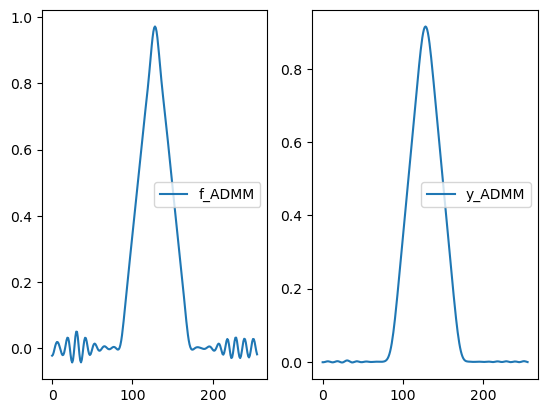

In [16]:
for j in range(20):
    f_ADMM,y_ADMM = next(itADMM)
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(f_ADMM,label = 'f_ADMM')
ax1.legend()
ax2.plot(y_ADMM,label='y_ADMM')
ax2.legend()

# FISTA
Run this cell until the duality gap is sufficiently small. 

In [5]:
for j in range(20):
    p_FISTA,Tstar_pFISTA = next(itFISTA)
f_FISTA = huber_setting.dualToPrimal(Tstar_pFISTA,argumentIsOperatorImage=True)
"""
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(p_FISTA,label = 'p_FISTA')
ax1.legend()
ax2.plot(f_FISTA,label='f_FISTA')
ax2.legend()
"""

2024-06-26 21:08:27,884 DEBUG FISTA                :: it.1: duality gap=2.334e-01
2024-06-26 21:08:27,891 DEBUG FISTA                :: it.2: duality gap=1.083e-01
2024-06-26 21:08:27,897 DEBUG FISTA                :: it.3: duality gap=8.321e-02
2024-06-26 21:08:27,903 DEBUG FISTA                :: it.4: duality gap=6.463e-02
2024-06-26 21:08:27,911 DEBUG FISTA                :: it.5: duality gap=5.556e-02
2024-06-26 21:08:27,916 DEBUG FISTA                :: it.6: duality gap=4.491e-02
2024-06-26 21:08:27,923 DEBUG FISTA                :: it.7: duality gap=3.020e-02
2024-06-26 21:08:27,928 DEBUG FISTA                :: it.8: duality gap=3.261e-02
2024-06-26 21:08:27,939 DEBUG FISTA                :: it.9: duality gap=2.725e-02
2024-06-26 21:08:27,946 DEBUG FISTA                :: it.10: duality gap=1.947e-02
2024-06-26 21:08:27,952 DEBUG FISTA                :: it.11: duality gap=2.248e-02
2024-06-26 21:08:27,961 DEBUG FISTA                :: it.12: duality gap=1.799e-02
2024-06-26 21

it= 20 duality gap: 0.07507243201690547


# PDHG
Run this cell until the duality gap is sufficiently small. 

In [136]:
for j in range(20):
    f_PDHG,p_PDHG = next(itPDHG)
"""
fig, (ax1,ax2) = plt.subplots(1,2)
ax1.plot(p_PDHG,label = 'p_PDHG')
ax1.legend()
ax2.plot(f_PDHG,label='f_PDHG')
ax2.legend()
"""


2024-06-25 21:03:57,546 DEBUG PDHG                 :: it. 301: duality gap=2.698e-07
2024-06-25 21:03:57,559 DEBUG PDHG                 :: it. 302: duality gap=2.576e-07
2024-06-25 21:03:57,571 DEBUG PDHG                 :: it. 303: duality gap=2.572e-07
2024-06-25 21:03:57,586 DEBUG PDHG                 :: it. 304: duality gap=2.674e-07
2024-06-25 21:03:57,604 DEBUG PDHG                 :: it. 305: duality gap=2.865e-07
2024-06-25 21:03:57,623 DEBUG PDHG                 :: it. 306: duality gap=3.126e-07
2024-06-25 21:03:57,637 DEBUG PDHG                 :: it. 307: duality gap=3.437e-07
2024-06-25 21:03:57,657 DEBUG PDHG                 :: it. 308: duality gap=3.776e-07
2024-06-25 21:03:57,672 DEBUG PDHG                 :: it. 309: duality gap=4.123e-07
2024-06-25 21:03:57,687 DEBUG PDHG                 :: it. 310: duality gap=4.457e-07
2024-06-25 21:03:57,700 DEBUG PDHG                 :: it. 311: duality gap=4.761e-07
2024-06-25 21:03:57,717 DEBUG PDHG                 :: it. 312: du

it: 320 duality gap: 4.570355668087611e-07


# Semismooth Newton method

The method gives a solution that looks better than those of FISTA and PDHG, but the duality gap is much larger. 
(Possibly the effective regularization parameter is wrong!)

In [40]:
#p_SS,Tstar_pSS = solverSS.run(stoprule=CountIterations(50))
#f_SS    = huber_setting.dualToPrimal(Tstar_pSS,argumentIsOperatorImage=True)
print('SSNewton duality gap - from dual:', huber_setting.dualityGap(dual=p_SS), 
      'from primal', huber_setting.dualityGap(primal=f_SS))

SSNewton duality gap - from dual: 112.33196001335378 from primal 12.091820020933412


# Plot results of all methods for comparison

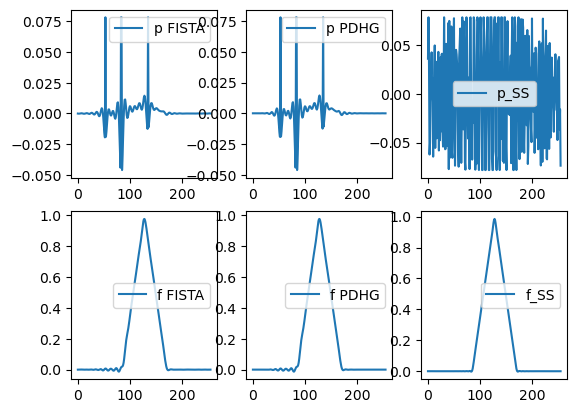

In [137]:
fig,((ax11,ax12,ax13),(ax21,ax22,ax23)) = plt.subplots(2,3)

ax11.plot(p_FISTA,label='p FISTA'); ax11.legend()
ax12.plot(solverPDHG.pstar,label='p PDHG');   ax12.legend()
ax13.plot(p_SS, label = 'p_SS');     ax13.legend()

ax21.plot(f_FISTA,label='f FISTA'); ax21.legend()
ax22.plot(f_PDHG,label='f PDHG');   ax22.legend()
ax23.plot(f_SS, label = 'f_SS');     ax23.legend()